In [1]:
import  numpy as np
import pandas as pd

data=pd.read_csv("spam.csv", encoding='latin-1')

1. DATA CLEANING 


In [2]:
## Dropping last 3 Columns as they have 90%+ NUll Values.

data=data.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])


In [3]:
# Renaming the columns for better understanding 
# v1 -> target , v2 -> text

data.rename(columns={'v1':'target','v2':'text'},inplace=True)
data.sample(5)

,target,text
4569,spam,Wanna have a laugh? Try CHIT-CHAT on your mobi...
5157,ham,K k:) sms chat with me.
3019,ham,I thank you so much for all you do with selfle...
2067,ham,Who's there say hi to our drugdealer
2964,ham,Not yet had..ya sapna aunty manege y'day hogid...


In [4]:
# Convert 'ham'->1 and 'spam' ->0 for processing

data['target']=data['target'].map({'ham':0,'spam':1})

data.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
# Chcek for missing values 

data.isna().sum() # No Null Values

#Check for dupliactes values 

data.duplicated().sum()  # 403 duplicated values

# Dropping duplicte values

data.drop_duplicates(keep='first',inplace=True)

data.shape

(5169, 2)

2. Exploratory Data Analysis (EDA)

<Axes: ylabel='count'>

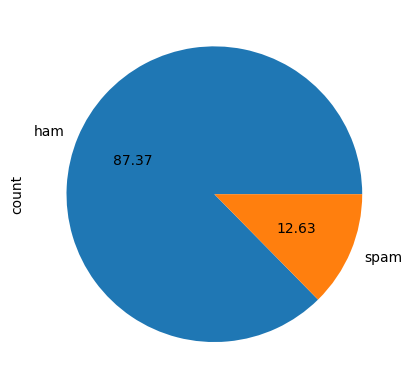

In [6]:
import matplotlib.pyplot as plt

# counting 1 and 0 in target

data['target'].value_counts().plot(kind='pie',labels=['ham','spam'],autopct="%0.2f")

In [7]:
import nltk
nltk.download('punkt_tab')



[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
# Countng characters in text message

data['no_of_characters']=data['text'].apply(len)
data.head()

,target,text,no_of_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [9]:
# counting words in text message

data['no_of_words']=data['text'].apply(lambda x:len( nltk.word_tokenize(x)))
data.sample(7)

,target,text,no_of_characters,no_of_words
919,0,Dont talk to him ever ok its my word.,37,10
3352,0,I emailed yifeng my part oredi.. Can Ì_ get it...,55,14
2758,0,What time. IÛ÷m out until prob 3 or so,39,10
5041,1,Jamster! To get your free wallpaper text HEART...,109,27
2599,0,"Gosh that , what a pain. Spose I better come t...",50,13
1525,0,Pls pls find out from aunt nike.,32,8
5087,0,"Good morning, im suffering from fever and dyse...",94,20


In [10]:
#counting sentences in text message

data['no_of_sentences']=data['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
data.head()

,target,text,no_of_characters,no_of_words,no_of_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [11]:
# Analysis for Ham i.e 0

data[data['target']==0][['no_of_characters','no_of_words','no_of_sentences']].describe()


,no_of_characters,no_of_words,no_of_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [12]:
# Analysis for Spam i.e 1

data[data['target']==1][['no_of_characters','no_of_words','no_of_sentences']].describe()

,no_of_characters,no_of_words,no_of_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='no_of_characters', ylabel='Count'>

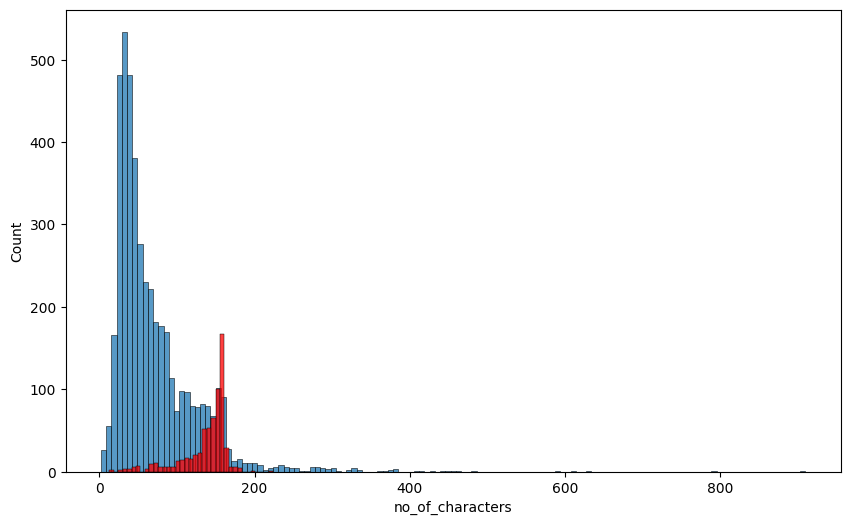

In [13]:
import seaborn as sns 

plt.figure(figsize=(10,6))
sns.histplot(data[data['target']==0]['no_of_characters'])
sns.histplot(data[data['target']==1]['no_of_characters'],color='red')

<Axes: >

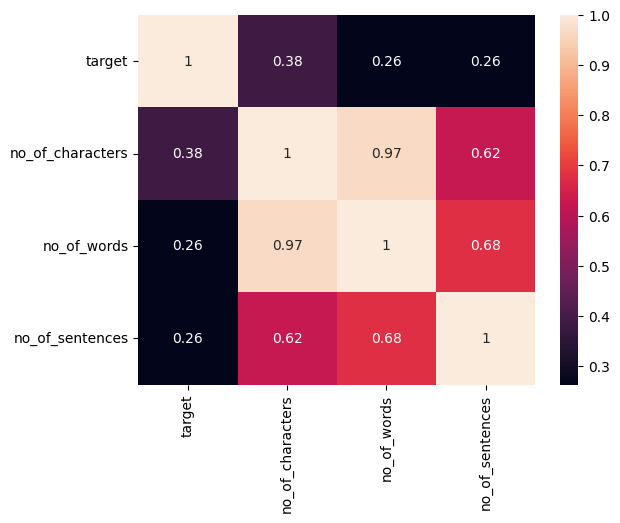

In [14]:
sns.heatmap(data[['target','no_of_characters','no_of_words','no_of_sentences']].corr(),annot=True)

3. DATA PREPROCESSING

In [15]:
## TEXT PROCESSING INVOLVES THESE STEPS ONLY


# 1. Lower case (for uniformity)
# 2. Tokenization (breakdown in words)
# 3. Removing special characters (@,!,&,etc)
# 4. Removing Stopwards and Punctuations
# 5. STtemming

In [16]:
## for step 4

nltk.download('stopwords')

import string
string.punctuation

from nltk.corpus import stopwords
stopwords.words('english')


# for step 5 
 
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [17]:
def transform(text):
  text=text.lower()
  text=nltk.word_tokenize(text)

  y=[]
  for i in text:
    if i.isalnum():
      y.append(i)

  text=y[:]
  y.clear()

  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(ps.stem(i))

  return " ".join(y)
  


data['transformed_text']=data['text'].apply(transform)


In [18]:
data.head() 

,target,text,no_of_characters,no_of_words,no_of_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [19]:
!pip install wordcloud

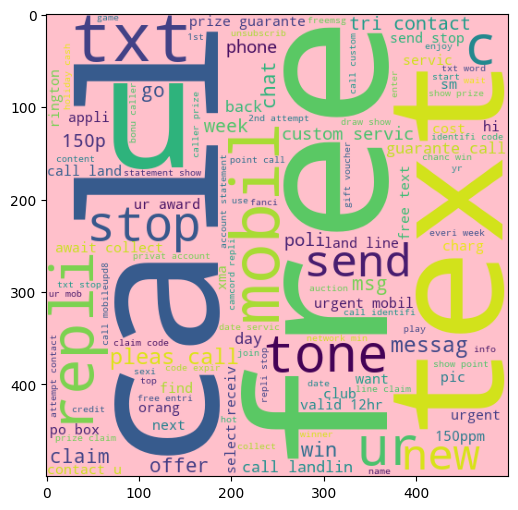

In [20]:
# Checking most common words in "SPAM" by WordCloud Visualization Diagram 
## IDEA --->>> Bigger the size of word -> More frequency of words

from wordcloud import WordCloud



wc=WordCloud(width=500,height=500,min_font_size=10,background_color='pink')

spam=wc.generate(data[data['target']==1]['transformed_text'].str.cat(sep=' '))


plt.figure(figsize=(10,6))
plt.imshow(spam)


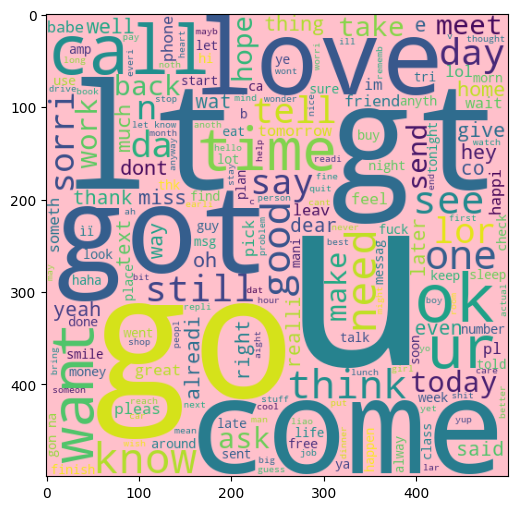

In [21]:
# Checking most common words in "HAM" by WordCloud Visualization Diagram 
## IDEA --->>> Bigger the size of word -> More frequency of words

ham=wc.generate(data[data['target']==0]['transformed_text'].str.cat(sep=' '))


plt.figure(figsize=(10,6))
plt.imshow(spam)

C:\Users\hp\AppData\Local\Temp\ipykernel_21716\4082663149.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0] ,y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1],palette='viridis')


Text(0, 0.5, 'Frequencies')

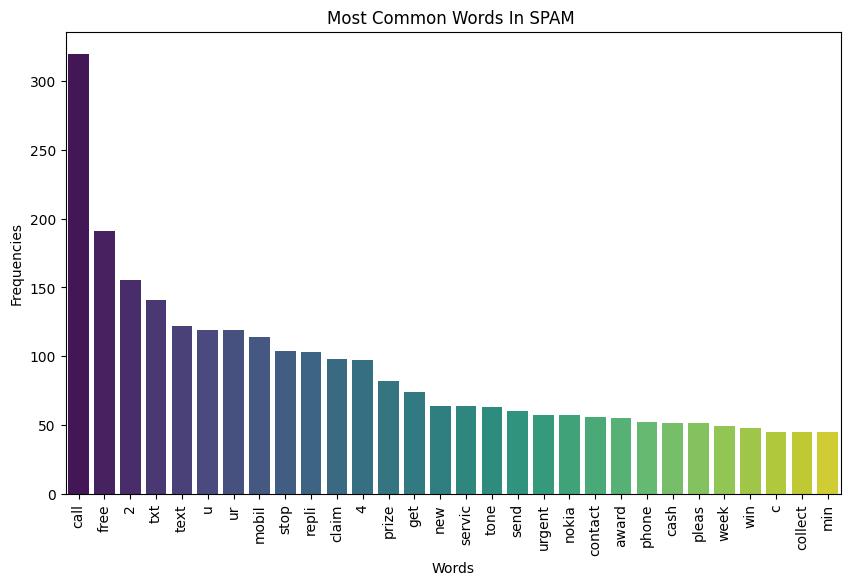

In [22]:
# Counting Most Frequent 30 words in SPAM 


spam_corpus=[]
for i in data[data['target']==1]['transformed_text'].to_list():
  for word in i.split():
    spam_corpus.append(word)

from collections import Counter
plt.figure(figsize=(10,6))
plt.xticks(rotation=90)
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0] ,y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1],palette='viridis')
plt.title('Most Common Words In SPAM ')
plt.xlabel('Words')
plt.ylabel('Frequencies')

C:\Users\hp\AppData\Local\Temp\ipykernel_21716\2074571985.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0] ,y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1],palette='viridis')


Text(0, 0.5, 'Frequencies')

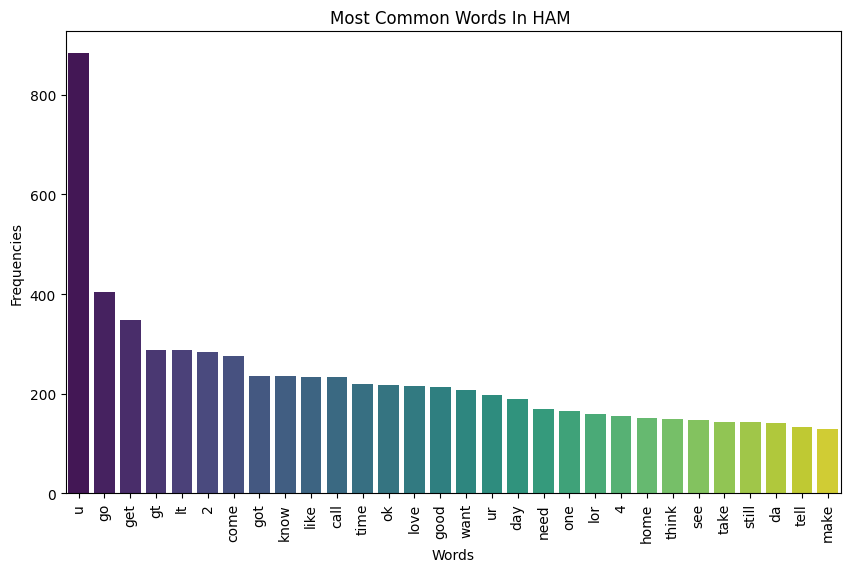

In [23]:
# Counting Most Frequent 30 words in HAM 


spam_corpus=[]
for i in data[data['target']==0]['transformed_text'].to_list():
  for word in i.split():
    spam_corpus.append(word)

from collections import Counter
plt.figure(figsize=(10,6))
plt.xticks(rotation=90)
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0] ,y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1],palette='viridis')
plt.title('Most Common Words In HAM ')
plt.xlabel('Words')
plt.ylabel('Frequencies')

4. MODEL BUILDING

In [24]:
# Using CountVectorizer

from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer()
x=cv.fit_transform(data['transformed_text']).toarray()
y=data['target'].values

In [25]:
# Splitting the data

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [26]:
# MODELS importing 

from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
gs=GaussianNB()
ms=MultinomialNB()
bs=BernoulliNB()

# Scoring Metrics importing

from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [27]:
# Model training for GaussianNB

gs.fit(x_train,y_train)

# Model Scoring for GaussianNB

y_preds=gs.predict(x_test)

print("The ACCURACY IS -> ",accuracy_score(y_test,y_preds))
print("The PRECISION SCORE IS -> ",precision_score(y_test,y_preds))
print("The CONFUSION MATRIX IS -> ", confusion_matrix(y_test,y_preds))




The ACCURACY IS ->  0.8800773694390716
The PRECISION SCORE IS ->  0.5315315315315315
The CONFUSION MATRIX IS ->  [[792 104]
 [ 20 118]]


In [28]:
# Model training for MultinomialNB

ms.fit(x_train,y_train)

# Model Scoring for MultinomialNB

y_preds1=ms.predict(x_test)

print("The ACCURACY IS -> ",accuracy_score(y_test,y_preds1))
print("The PRECISION SCORE IS -> ",precision_score(y_test,y_preds1))
print("The CONFUSION MATRIX IS -> ", confusion_matrix(y_test,y_preds1))




The ACCURACY IS ->  0.9642166344294004
The PRECISION SCORE IS ->  0.8344370860927153
The CONFUSION MATRIX IS ->  [[871  25]
 [ 12 126]]


In [29]:
# Model training for BernoulliNB

bs.fit(x_train,y_train)

# Model Scoring for BernoulliNB

y_preds2=bs.predict(x_test)

print("The ACCURACY IS -> ",accuracy_score(y_test,y_preds2))
print("The PRECISION SCORE IS -> ",precision_score(y_test,y_preds2))
print("The CONFUSION MATRIX IS -> ", confusion_matrix(y_test,y_preds2))




The ACCURACY IS ->  0.9700193423597679
The PRECISION SCORE IS ->  0.9734513274336283
The CONFUSION MATRIX IS ->  [[893   3]
 [ 28 110]]


In [36]:
# Using TfidfVectorizer

from sklearn.feature_extraction.text import TfidfVectorizer
tf=TfidfVectorizer(max_features=3000)
x1=tf.fit_transform(data['transformed_text']).toarray()
y1=data['target'].values

In [37]:
# Splitting the data

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x1,y1,test_size=0.2,random_state=2)

In [38]:
# Model training for GaussianNB

gs.fit(x_train,y_train)

# Model Scoring for GaussianNB

y_preds=gs.predict(x_test)

print("The ACCURACY IS -> ",accuracy_score(y_test,y_preds))
print("The PRECISION SCORE IS -> ",precision_score(y_test,y_preds))
print("The CONFUSION MATRIX IS -> ", confusion_matrix(y_test,y_preds))

The ACCURACY IS ->  0.874274661508704
The PRECISION SCORE IS ->  0.5181818181818182
The CONFUSION MATRIX IS ->  [[790 106]
 [ 24 114]]


In [39]:
# Model training for MultinomialNB

ms.fit(x_train,y_train)

# Model Scoring for MultinomialNB

y_preds1=ms.predict(x_test)

print("The ACCURACY IS -> ",accuracy_score(y_test,y_preds1))
print("The PRECISION SCORE IS -> ",precision_score(y_test,y_preds1))
print("The CONFUSION MATRIX IS -> ", confusion_matrix(y_test,y_preds1))


The ACCURACY IS ->  0.9709864603481625
The PRECISION SCORE IS ->  1.0
The CONFUSION MATRIX IS ->  [[896   0]
 [ 30 108]]


In [40]:
# Model training for BernoulliNB

bs.fit(x_train,y_train)

# Model Scoring for BernoulliNB

y_preds2=bs.predict(x_test)

print("The ACCURACY IS -> ",accuracy_score(y_test,y_preds2))
print("The PRECISION SCORE IS -> ",precision_score(y_test,y_preds2))
print("The CONFUSION MATRIX IS -> ", confusion_matrix(y_test,y_preds2))

The ACCURACY IS ->  0.9835589941972921
The PRECISION SCORE IS ->  0.991869918699187
The CONFUSION MATRIX IS ->  [[895   1]
 [ 16 122]]


In [41]:
import pickle
pickle.dump(tf,open('vectorizer.pkl','wb'))
pickle.dump(ms,open('model.pkl','wb'))